# Notebook 3 — Homografía

**TFM: Análisis de tenis mediante Computer Vision**

Objetivo: estimar la homografía que proyecta coordenadas en píxeles del frame a coordenadas reales (metros) sobre el plano de la pista, y proyectar las trayectorias de jugadores y pelota generadas por los notebooks 1 y 2.

**Requisitos:** `Kernel -> Restart & Run All`
**Dependencias:** `opencv-python`, `numpy`, `pandas`, `matplotlib`

## Índice

1. Configuración
2. Selección interactiva de los puntos de pista
   2.1 Selección con clics
   2.2 Guardar los puntos clicados
   2.3 Vista de los puntos seleccionados
3. Cálculo de la matriz de homografía
   3.1 Validación visual — pista proyectada sobre el frame
4. Proyección de jugadores
   4.1 Posiciones reales sobre canvas 2D de pista
5. Proyección de la pelota
6. Exportar CSVs proyectados

In [16]:
# ── Stdlib ──
import json
from pathlib import Path

# ── Numérico / datos ──
import numpy as np
import pandas as pd

# ── Visión artificial ──
import cv2

# ── Visualización ──
import matplotlib.pyplot as plt

## 1. Configuración

Rutas, dimensiones reales de pista ITF y clip de referencia para la selección de puntos.

In [17]:
# !python -m pip install ipywidgets

In [18]:
# ----- Rutas -----
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "Dataset"
OUTPUTS_ROOT = PROJECT_ROOT / "outputs"
TRACKING_DIR = OUTPUTS_ROOT / "tracking"
HOMOGRAPHY_DIR = OUTPUTS_ROOT / "homography"
PROJECTED_DIR = OUTPUTS_ROOT / "projected"
HOMOGRAPHY_DIR.mkdir(parents=True, exist_ok=True)
PROJECTED_DIR.mkdir(parents=True, exist_ok=True)

PLAYER_CSV       = TRACKING_DIR / "player_positions.csv"
BALL_CSV         = TRACKING_DIR / "ball_positions.csv"
COURT_POINTS_FILE = HOMOGRAPHY_DIR / "court_points.json"
PLAYER_REAL_CSV  = PROJECTED_DIR / "player_real_coords.csv"
BALL_REAL_CSV    = PROJECTED_DIR / "ball_real_coords.csv"

# ----- Clip de referencia para seleccionar las esquinas de la pista -----
GAME = "game1"
CLIP = "Clip1"
CLIP_DIR = DATASET_ROOT / GAME / CLIP
REF_FRAME = "0000.jpg"

# ----- Dimensiones reales de pista ITF (en metros) -----
COURT_TYPE = "singles"            # "singles" o "doubles"
COURT_LENGTH = 23.77              # largo (eje Y en mundo)
COURT_WIDTH_SINGLES = 8.23
COURT_WIDTH_DOUBLES = 10.97
COURT_WIDTH = COURT_WIDTH_SINGLES if COURT_TYPE == "singles" else COURT_WIDTH_DOUBLES

# Línea de servicio y red (referencias visuales)
SERVICE_LINE_FROM_NET = 6.40      # distancia red <-> línea de saque
NET_Y = COURT_LENGTH / 2.0

# ----- Puntos del mundo (en orden) -----
# Orden de clic exigido en la imagen:
#   1) esquina inferior-izquierda  (cerca cámara, izquierda)
#   2) esquina inferior-derecha    (cerca cámara, derecha)
#   3) esquina superior-derecha    (fondo, derecha)
#   4) esquina superior-izquierda  (fondo, izquierda)

WORLD_POINTS = np.array([
    [0.0,          0.0],
    [COURT_WIDTH,  0.0],
    [COURT_WIDTH,  COURT_LENGTH],
    [0.0,          COURT_LENGTH],
], dtype=np.float32)

# ----- Puntos manuales de respaldo -----
# Si la selección interactiva no funciona en tu entorno, rellena estos 4
# pares (x_pixel, y_pixel) y reejecuta la celda de carga.
MANUAL_POINTS = None              # ej. [[286, 660], [995, 660], [833, 280], [445, 280]]

# ----- Márgenes del canvas de visualización (metros) -----
# Los jugadores suelen situarse varios metros fuera de las líneas.
# MARGIN_Y: detrás de las líneas de fondo (los jugadores retroceden 3-6 m)
# MARGIN_X: fuera de las líneas laterales (1-3 m)
MARGIN_Y = 5.0
MARGIN_X = 3.0

print(f"Clip de referencia: {CLIP_DIR / REF_FRAME}")
print(f"Pista: {COURT_TYPE}  {COURT_WIDTH:.2f} m x {COURT_LENGTH:.2f} m")
print(f"Puntos guardados en: {COURT_POINTS_FILE}")
assert (CLIP_DIR / REF_FRAME).exists(), f"No se encuentra el frame: {CLIP_DIR / REF_FRAME}"
assert PLAYER_CSV.exists(), f"Falta {PLAYER_CSV}. Ejecuta antes el notebook 01."


Clip de referencia: c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\Dataset\game1\Clip1\0000.jpg
Pista: singles  8.23 m x 23.77 m
Puntos guardados en: c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\homography\court_points.json


## 2. Selección interactiva de los puntos de pista

Si `court_points.json` ya existe se cargan los puntos guardados. En caso contrario, ejecuta la celda interactiva siguiente, clica las 4 esquinas en el orden indicado y luego ejecuta la celda de guardado.

In [19]:
ref_frame_path = CLIP_DIR / REF_FRAME
first_frame = cv2.cvtColor(cv2.imread(str(ref_frame_path)), cv2.COLOR_BGR2RGB)
FRAME_H, FRAME_W = first_frame.shape[:2]
print(f"Frame de referencia: {FRAME_W} x {FRAME_H}")

image_points = None
if COURT_POINTS_FILE.exists():
    with open(COURT_POINTS_FILE, "r", encoding="utf-8") as f:
        court_data = json.load(f)
    image_points = np.array(court_data["image_points"], dtype=np.float32)
    print(f"Puntos cargados de {COURT_POINTS_FILE}:")
    for i, (x, y) in enumerate(image_points, start=1):
        print(f"  P{i}: ({x:.1f}, {y:.1f})")
elif MANUAL_POINTS is not None:
    image_points = np.array(MANUAL_POINTS, dtype=np.float32)
    print("Usando MANUAL_POINTS (selección no interactiva).")
else:
    print("No hay puntos guardados. Ejecuta la celda interactiva siguiente.")


Frame de referencia: 1280 x 720
Puntos cargados de c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\homography\court_points.json:
  P1: (308.5, 531.4)
  P2: (972.4, 528.3)
  P3: (807.2, 165.2)
  P4: (476.8, 168.3)


### 2.1 Selección con clics

Backend interactivo (`%matplotlib widget` en VS Code / Jupyter Lab, o `%matplotlib notebook` en Jupyter clásico). Clica las 4 esquinas en este orden:

1. **inferior-izquierda** (cerca de la cámara, izquierda)
2. **inferior-derecha** (cerca de la cámara, derecha)
3. **superior-derecha** (fondo, derecha)
4. **superior-izquierda** (fondo, izquierda)

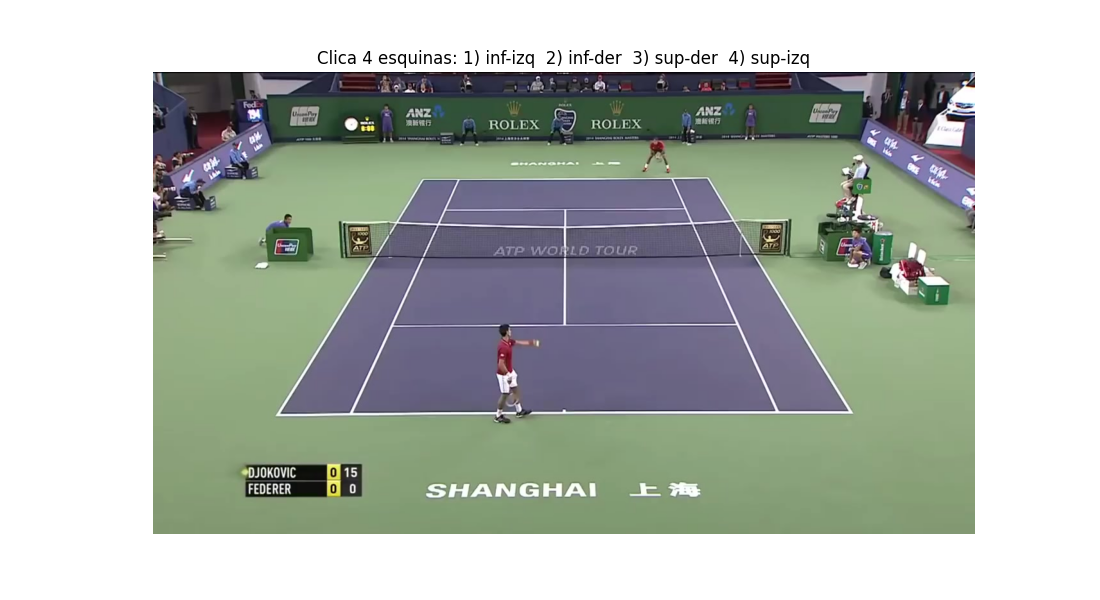

In [20]:
%matplotlib widget

clicked_points = []

fig_sel, ax_sel = plt.subplots(figsize=(11, 6))
ax_sel.imshow(first_frame)
ax_sel.set_title("Clica 4 esquinas: 1) inf-izq  2) inf-der  3) sup-der  4) sup-izq")
ax_sel.axis("off")

LABELS_SEL = ["1: inf-izq", "2: inf-der", "3: sup-der", "4: sup-izq"]

def _on_click(event):
    if event.inaxes != ax_sel or event.xdata is None or len(clicked_points) >= 4:
        return
    clicked_points.append([float(event.xdata), float(event.ydata)])
    n = len(clicked_points)
    ax_sel.plot(event.xdata, event.ydata, "o", color="red", ms=10, mec="white", mew=2)
    ax_sel.text(event.xdata + 8, event.ydata - 8, LABELS_SEL[n - 1],
                color="red", fontsize=10, weight="bold",
                bbox=dict(facecolor="white", edgecolor="red", alpha=0.7, pad=2))
    if n >= 2:
        pts = np.array(clicked_points)
        # cierra polígono cuando hay 4
        closing = np.vstack([pts, pts[:1]]) if n == 4 else pts
        ax_sel.plot(closing[:, 0], closing[:, 1], "-", color="yellow", lw=1.2)
    fig_sel.canvas.draw_idle()

_cid = fig_sel.canvas.mpl_connect("button_press_event", _on_click)
plt.show()


### 2.2 Guardar los puntos clicados

In [21]:
%matplotlib inline
if len(clicked_points) == 4:
    image_points = np.array(clicked_points, dtype=np.float32)
    payload = {
        "clip": f"{GAME}/{CLIP}",
        "reference_frame": REF_FRAME,
        "frame_size": [int(FRAME_W), int(FRAME_H)],
        "court_type": COURT_TYPE,
        "image_points": image_points.tolist(),
        "world_points": WORLD_POINTS.tolist(),
        "point_order": ["bottom_left", "bottom_right", "top_right", "top_left"],
    }
    with open(COURT_POINTS_FILE, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    print(f"Guardado {COURT_POINTS_FILE}")
    for i, (x, y) in enumerate(image_points, start=1):
        print(f"  P{i}: ({x:.1f}, {y:.1f})")
elif image_points is not None:
    print("image_points ya estaba cargado de disco. No se sobrescribe.")
else:
    print(f"Solo {len(clicked_points)} puntos clicados. Vuelve a la celda interactiva.")


image_points ya estaba cargado de disco. No se sobrescribe.


### 2.3 Vista de los puntos seleccionados

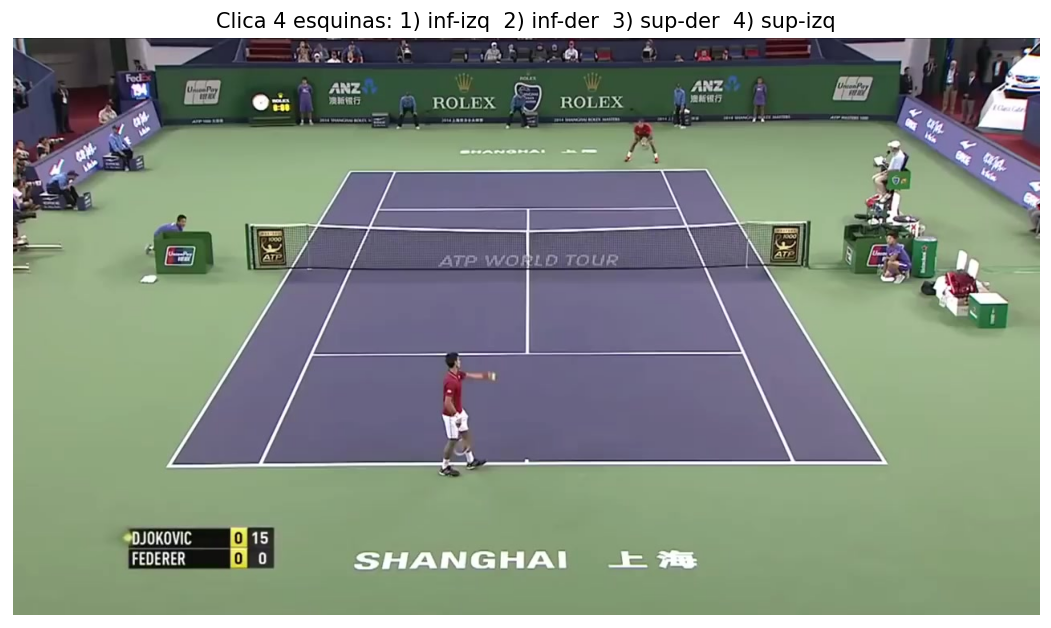

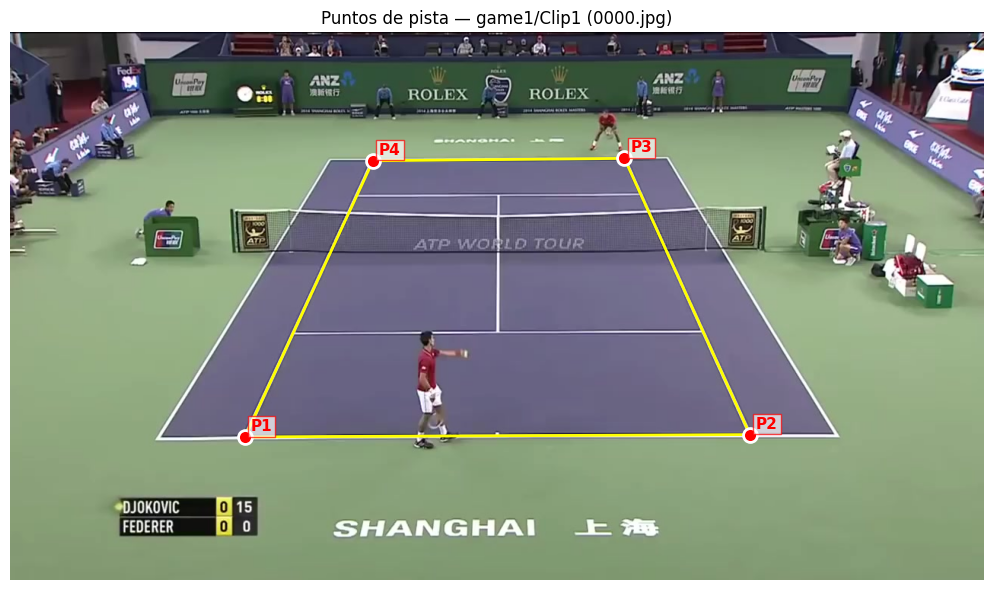

In [22]:
assert image_points is not None and image_points.shape == (4, 2), \
    "Faltan los 4 puntos de pista. Ejecuta la selección interactiva o configura MANUAL_POINTS."

fig, ax = plt.subplots(figsize=(11, 6))
ax.imshow(first_frame)
poly = np.vstack([image_points, image_points[:1]])
ax.plot(poly[:, 0], poly[:, 1], "-", color="yellow", lw=2)
for i, (x, y) in enumerate(image_points, start=1):
    ax.plot(x, y, "o", color="red", ms=10, mec="white", mew=2)
    ax.text(x + 8, y - 8, f"P{i}", color="red", fontsize=11, weight="bold",
            bbox=dict(facecolor="white", edgecolor="red", alpha=0.7, pad=2))
ax.set_title(f"Puntos de pista — {GAME}/{CLIP} ({REF_FRAME})")
ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Cálculo de la matriz de homografía

Usamos `cv2.findHomography` con los 4 pares píxel ↔ mundo. Con exactamente 4 puntos no degenerados el sistema tiene solución cerrada (no necesitamos RANSAC).

In [23]:
H, _mask = cv2.findHomography(image_points, WORLD_POINTS, method=0)
H_inv = np.linalg.inv(H)
print("Matriz H (píxel -> mundo, en metros):")
print(H)
print("\nMatriz H^-1 (mundo -> píxel):")
print(H_inv)


def project_points(pts_xy, M):
    """Proyecta un array (N, 2) con la homografía M (3x3)."""
    pts = np.asarray(pts_xy, dtype=np.float64).reshape(-1, 1, 2)
    out = cv2.perspectiveTransform(pts, M)
    return out.reshape(-1, 2)


# Sanity check: proyectando los 4 puntos imagen debemos recuperar los del mundo
recovered = project_points(image_points, H)
err = np.linalg.norm(recovered - WORLD_POINTS, axis=1)
print(f"\nError reproyección esquinas (m): {err}")
print(f"Error medio: {err.mean():.4f} m  |  max: {err.max():.4f} m")


Matriz H (píxel -> mundo, en metros):
[[ 4.90565438e-02  2.27386561e-02 -2.72164355e+01]
 [-6.01307586e-04 -1.28078545e-01  6.82525117e+01]
 [ 7.68531732e-05  5.43966864e-03  1.00000000e+00]]

Matriz H^-1 (mundo -> píxel):
[[ 2.03464924e+01  6.95888692e+00  7.87974872e+01]
 [-2.38230776e-01 -2.08408447e+00  1.35760207e+02]
 [-2.67796020e-04  1.08019164e-02  2.55453622e-01]]

Error reproyección esquinas (m): [3.63021431e-15 7.41374398e-15 7.32410688e-15 1.46695061e-14]
Error medio: 0.0000 m  |  max: 0.0000 m


### 3.1 Validación visual — pista proyectada sobre el frame

Dibujamos la rejilla teórica de la pista (líneas de fondo, laterales, red y líneas de saque) usando `H^-1`. Si la homografía es correcta las líneas deben coincidir con las marcas reales del frame.

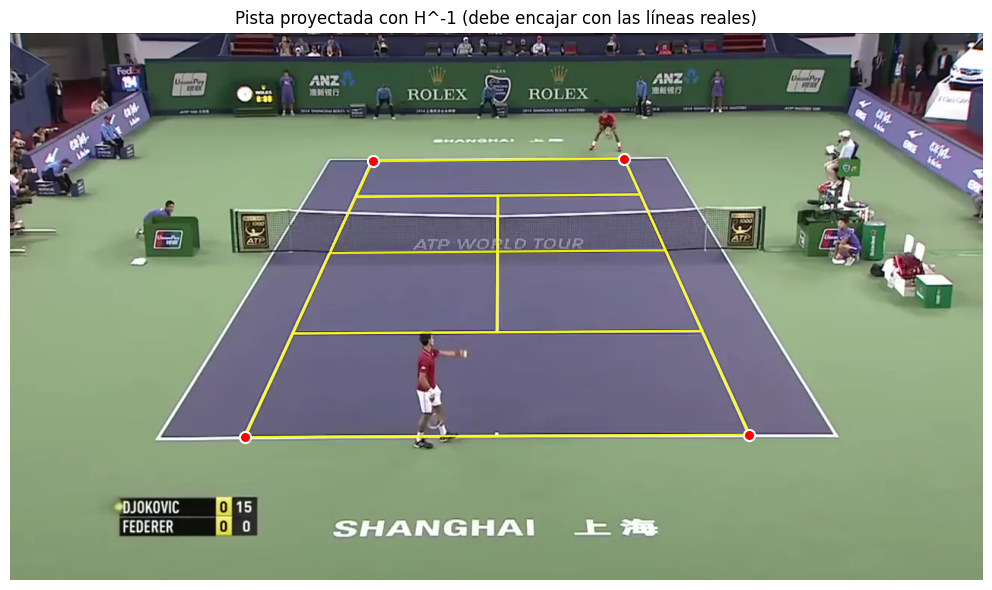

In [24]:
def world_grid_lines():
    """Devuelve la lista de segmentos (en metros) de las líneas principales."""
    W, L = COURT_WIDTH, COURT_LENGTH
    s_near = NET_Y - SERVICE_LINE_FROM_NET
    s_far  = NET_Y + SERVICE_LINE_FROM_NET
    return [
        # Perímetro
        ((0, 0), (W, 0)),
        ((W, 0), (W, L)),
        ((W, L), (0, L)),
        ((0, L), (0, 0)),
        # Red
        ((0, NET_Y), (W, NET_Y)),
        # Líneas de saque
        ((0, s_near), (W, s_near)),
        ((0, s_far),  (W, s_far)),
        # Pasillo central de saque
        ((W / 2, s_near), (W / 2, s_far)),
    ]


def draw_court_overlay(ax, M_world_to_pixel, color="yellow", lw=1.5):
    for (p0, p1) in world_grid_lines():
        seg = project_points(np.array([p0, p1]), M_world_to_pixel)
        ax.plot(seg[:, 0], seg[:, 1], "-", color=color, lw=lw, alpha=0.9)


fig, ax = plt.subplots(figsize=(11, 6))
ax.imshow(first_frame)
draw_court_overlay(ax, H_inv, color="yellow", lw=1.6)
for i, (x, y) in enumerate(image_points, start=1):
    ax.plot(x, y, "o", color="red", ms=8, mec="white", mew=1.5)
ax.set_title("Pista proyectada con H^-1 (debe encajar con las líneas reales)")
ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Proyección de jugadores

Leemos `player_positions.csv` y aplicamos `H` al punto de pie `(foot_x, foot_y)` de cada jugador.

In [25]:
df_players = pd.read_csv(PLAYER_CSV)
print(f"player_positions: {len(df_players)} filas | columnas: {list(df_players.columns)}")
df_players.head()


player_positions: 414 filas | columnas: ['clip', 'frame', 'player_id', 'player_label', 'foot_x', 'foot_y', 'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2', 'confidence']


,clip,frame,player_id,player_label,foot_x,foot_y,bbox_x1,bbox_y1,bbox_x2,bbox_y2,confidence
0,game1/Clip1,0,1,player_bottom,566.261047,548.841553,529.358215,391.987366,603.163879,548.841553,0.881487
1,game1/Clip1,0,2,player_top,783.689575,157.894043,760.873047,102.656708,806.506165,157.894043,0.818488
2,game1/Clip1,1,1,player_bottom,565.585938,548.736877,528.727173,391.975769,602.444763,548.736877,0.868475
3,game1/Clip1,1,2,player_top,783.696533,157.949646,760.477051,101.714828,806.915955,157.949646,0.819036
4,game1/Clip1,2,1,player_bottom,563.739746,547.907104,526.326965,388.300598,601.152588,547.907104,0.858075


In [26]:
player_xy = df_players[["foot_x", "foot_y"]].to_numpy()
real_xy = project_points(player_xy, H)
df_players_proj = df_players.copy()
df_players_proj["real_x"] = real_xy[:, 0]
df_players_proj["real_y"] = real_xy[:, 1]

# Conservar etiqueta legible si la columna existe (notebook 1 la añade)
id_col = "player_label" if "player_label" in df_players_proj.columns else "player_id"
print(f"Identificador de jugador usado: {id_col}")
df_players_proj[["clip", "frame", id_col, "foot_x", "foot_y", "real_x", "real_y"]].head()


Identificador de jugador usado: player_label


,clip,frame,player_label,foot_x,foot_y,real_x,real_y
0,game1/Clip1,0,player_bottom,566.261047,548.841553,3.237076,-0.591410
1,game1/Clip1,0,player_top,783.689575,157.894043,7.721749,24.781372
2,game1/Clip1,1,player_bottom,565.585938,548.736877,3.228763,-0.588073
3,game1/Clip1,1,player_top,783.696533,157.949646,7.721366,24.773747
4,game1/Clip1,2,player_bottom,563.739746,547.907104,3.205302,-0.562065


### 4.1 Posiciones reales sobre canvas 2D de pista

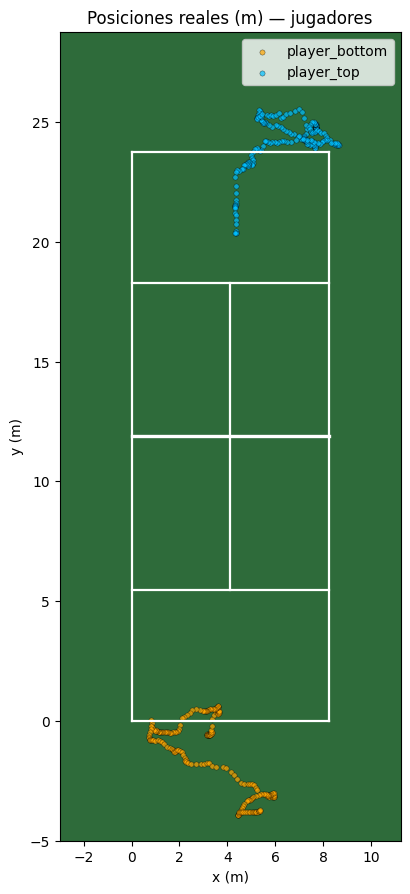

In [27]:
def draw_court_2d(ax, court_width=COURT_WIDTH, court_length=COURT_LENGTH,
                  margin_x=MARGIN_X, margin_y=MARGIN_Y):
    """Dibuja la pista de tenis en metros sobre un eje matplotlib."""
    W, L = court_width, court_length
    s_near = NET_Y - SERVICE_LINE_FROM_NET
    s_far  = NET_Y + SERVICE_LINE_FROM_NET
    lines = [
        ((0, 0), (W, 0)),
        ((W, 0), (W, L)),
        ((W, L), (0, L)),
        ((0, L), (0, 0)),
        ((0, s_near), (W, s_near)),
        ((0, s_far),  (W, s_far)),
        ((W / 2, s_near), (W / 2, s_far)),
    ]
    for (p0, p1) in lines:
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color="white", lw=1.6)
    ax.plot([0, W], [NET_Y, NET_Y], color="white", lw=2.4)
    ax.set_facecolor("#2e6b3a")
    ax.set_xlim(-margin_x, W + margin_x)
    ax.set_ylim(-margin_y, L + margin_y)
    ax.set_aspect("equal")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")


# figsize proporcional al canvas real (pista + márgenes)
_canvas_w = COURT_WIDTH  + 2 * MARGIN_X
_canvas_h = COURT_LENGTH + 2 * MARGIN_Y
_fig_h = 10
_fig_w = round(_fig_h * _canvas_w / _canvas_h, 1)

fig, ax = plt.subplots(figsize=(_fig_w, _fig_h))
draw_court_2d(ax)
colors = {"player_top": "deepskyblue", "player_bottom": "orange"}
if id_col == "player_label":
    for label, sub in df_players_proj.groupby("player_label"):
        ax.scatter(sub["real_x"], sub["real_y"], s=14, alpha=0.7,
                   color=colors.get(label, "magenta"), label=label,
                   edgecolors="black", linewidths=0.3)
else:
    for pid, sub in df_players_proj.groupby("player_id"):
        ax.scatter(sub["real_x"], sub["real_y"], s=14, alpha=0.7,
                   label=f"player_{pid}", edgecolors="black", linewidths=0.3)
ax.legend(loc="upper right")
ax.set_title("Posiciones reales (m) — jugadores")
plt.tight_layout()
plt.show()


## 5. Proyección de la pelota

Leemos `ball_positions.csv` y proyectamos `(ball_x, ball_y)`. Sólo se proyectan filas con coordenadas válidas (`ball_x`, `ball_y` no nulas).

In [28]:
if BALL_CSV.exists():
    df_ball = pd.read_csv(BALL_CSV)
    print(f"ball_positions: {len(df_ball)} filas | columnas: {list(df_ball.columns)}")
else:
    df_ball = None
    print(f"AVISO: no existe {BALL_CSV}. Ejecuta el notebook 02 para generarlo.")
df_ball.head() if df_ball is not None else None


AVISO: no existe c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\tracking\ball_positions.csv. Ejecuta el notebook 02 para generarlo.


In [29]:
if df_ball is not None:
    df_ball_proj = df_ball.copy()
    mask_valid = df_ball_proj["ball_x"].notna() & df_ball_proj["ball_y"].notna()
    real_ball = np.full((len(df_ball_proj), 2), np.nan, dtype=np.float64)
    if mask_valid.any():
        real_ball[mask_valid.values] = project_points(
            df_ball_proj.loc[mask_valid, ["ball_x", "ball_y"]].to_numpy(), H
        )
    df_ball_proj["ball_real_x"] = real_ball[:, 0]
    df_ball_proj["ball_real_y"] = real_ball[:, 1]

    # Plot
    fig, ax = plt.subplots(figsize=(_fig_w, _fig_h))
    draw_court_2d(ax)
    valid = df_ball_proj.dropna(subset=["ball_real_x", "ball_real_y"])
    no_bounce = valid[valid["is_bounce"] != 1]
    bounce    = valid[valid["is_bounce"] == 1]
    ax.scatter(no_bounce["ball_real_x"], no_bounce["ball_real_y"],
               s=8, color="yellow", alpha=0.55, label="trayectoria")
    ax.scatter(bounce["ball_real_x"], bounce["ball_real_y"],
               s=70, color="red", marker="X", edgecolors="white",
               linewidths=1.0, label=f"rebotes (n={len(bounce)})")
    ax.legend(loc="upper right")
    ax.set_title("Trayectoria de la pelota — coordenadas reales (m)")
    plt.tight_layout()
    plt.show()
else:
    df_ball_proj = None
    print("Sección omitida: no hay ball_positions.csv.")


Sección omitida: no hay ball_positions.csv.


## 6. Exportar CSVs proyectados

In [30]:
cols_player_out = ["clip", "frame", id_col, "real_x", "real_y"]
df_players_out = df_players_proj[cols_player_out].rename(columns={id_col: "player_id"})
df_players_out.to_csv(PLAYER_REAL_CSV, index=False)
print(f"Guardado {len(df_players_out)} filas en {PLAYER_REAL_CSV}")
df_players_out.head()


Guardado 414 filas en c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\projected\player_real_coords.csv


,clip,frame,player_id,real_x,real_y
0,game1/Clip1,0,player_bottom,3.237076,-0.591410
1,game1/Clip1,0,player_top,7.721749,24.781372
2,game1/Clip1,1,player_bottom,3.228763,-0.588073
3,game1/Clip1,1,player_top,7.721366,24.773747
4,game1/Clip1,2,player_bottom,3.205302,-0.562065


In [31]:
if df_ball_proj is not None:
    df_ball_out = df_ball_proj[["clip", "frame", "ball_real_x", "ball_real_y", "is_bounce"]]
    df_ball_out.to_csv(BALL_REAL_CSV, index=False)
    print(f"Guardado {len(df_ball_out)} filas en {BALL_REAL_CSV}")
    df_ball_out.head()
else:
    print(f"No se exporta {BALL_REAL_CSV} (falta ball_positions.csv).")


No se exporta c:\Users\cosme\Documents\UNAV\TFM\ProyectoTFM\outputs\projected\ball_real_coords.csv (falta ball_positions.csv).
